# COMP4318/5318 Assignment 2: Image Classification

### Group number: 153
SID1: 540430668
SID2: 540776016
SID3: ...
SID4: ... 

This template notebook includes code to load the  dataset and a skeleton for the main sections that should be included in the notebook. Please stick to this struture for your submitted notebook.

Please focus on making your code clear, with appropriate variable names and whitespace. Include comments and markdown text to aid the readability of your code where relevant. See the specification and marking criteria in the associated specification to guide you when completing your implementation.

## Setup and dependencies
Please use this section to list and set up all your required libraries/dependencies and your plotting environment. 

In [38]:
import os
# Suppress TensorFlow C++ INFO/WARNING (Metal device, NUMA, etc.); must run before importing tensorflow.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import time
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV

from scikeras.wrappers import KerasClassifier

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 5318

processed_dir = Path('processed')
output_dir = Path('output')
processed_dir.mkdir(exist_ok=True)
output_dir.mkdir(exist_ok=True)

## 1. Data loading, exploration, and preprocessing


Code to load the dataset is provided in the following cell. Please proceed with your data exploration and preprocessing in the remainder of this section.

In [2]:
# Load the dataset training and test sets as numpy arrays
# assuming Assignment2Data folder is present in the same directory 
# as the notebook
X_train = np.load('Assignment2Data/X_train.npy')
y_train = np.load('Assignment2Data/y_train.npy')
X_test = np.load('Assignment2Data/X_test.npy')
y_test = np.load('Assignment2Data/y_test.npy')

### Dataset overview
Start by checking dataset size, datatype, and label coverage before plotting.

In [3]:
print(f'X_train shape: {X_train.shape}, dtype: {X_train.dtype}')
print(f'y_train shape: {y_train.shape}, dtype: {y_train.dtype}')
print(f'X_test shape: {X_test.shape}, dtype: {X_test.dtype}')
print(f'y_test shape: {y_test.shape}, dtype: {y_test.dtype}')
print(f'Pixel range in training data: [{X_train.min()}, {X_train.max()}]')
print(f'Unique class labels: {np.unique(y_train)}')

X_train shape: (32000, 28, 28, 3), dtype: uint8
y_train shape: (32000,), dtype: uint8
X_test shape: (8000, 28, 28, 3), dtype: uint8
y_test shape: (8000,), dtype: uint8
Pixel range in training data: [0, 255]
Unique class labels: [0 1 2 3 4 5 6 7 8]


### Class distribution
This bar chart checks whether the classes are balanced in the training split.

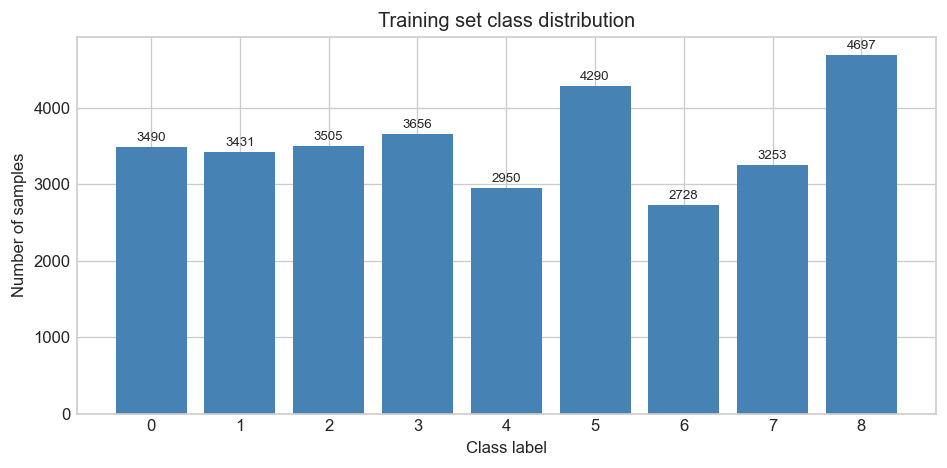

In [5]:
class_ids, class_counts = np.unique(y_train, return_counts=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(class_ids.astype(str), class_counts, color='steelblue')
ax.set_title('Training set class distribution')
ax.set_xlabel('Class label')
ax.set_ylabel('Number of samples')
for idx, count in enumerate(class_counts):
    ax.text(idx, count + 40, str(count), ha='center', va='bottom', fontsize=8)
fig.tight_layout()
fig.savefig(output_dir / 'class_distribution.png', bbox_inches='tight')
plt.show()

### Sample images from each class
Display a few examples per class to inspect intra-class variation and class similarity.

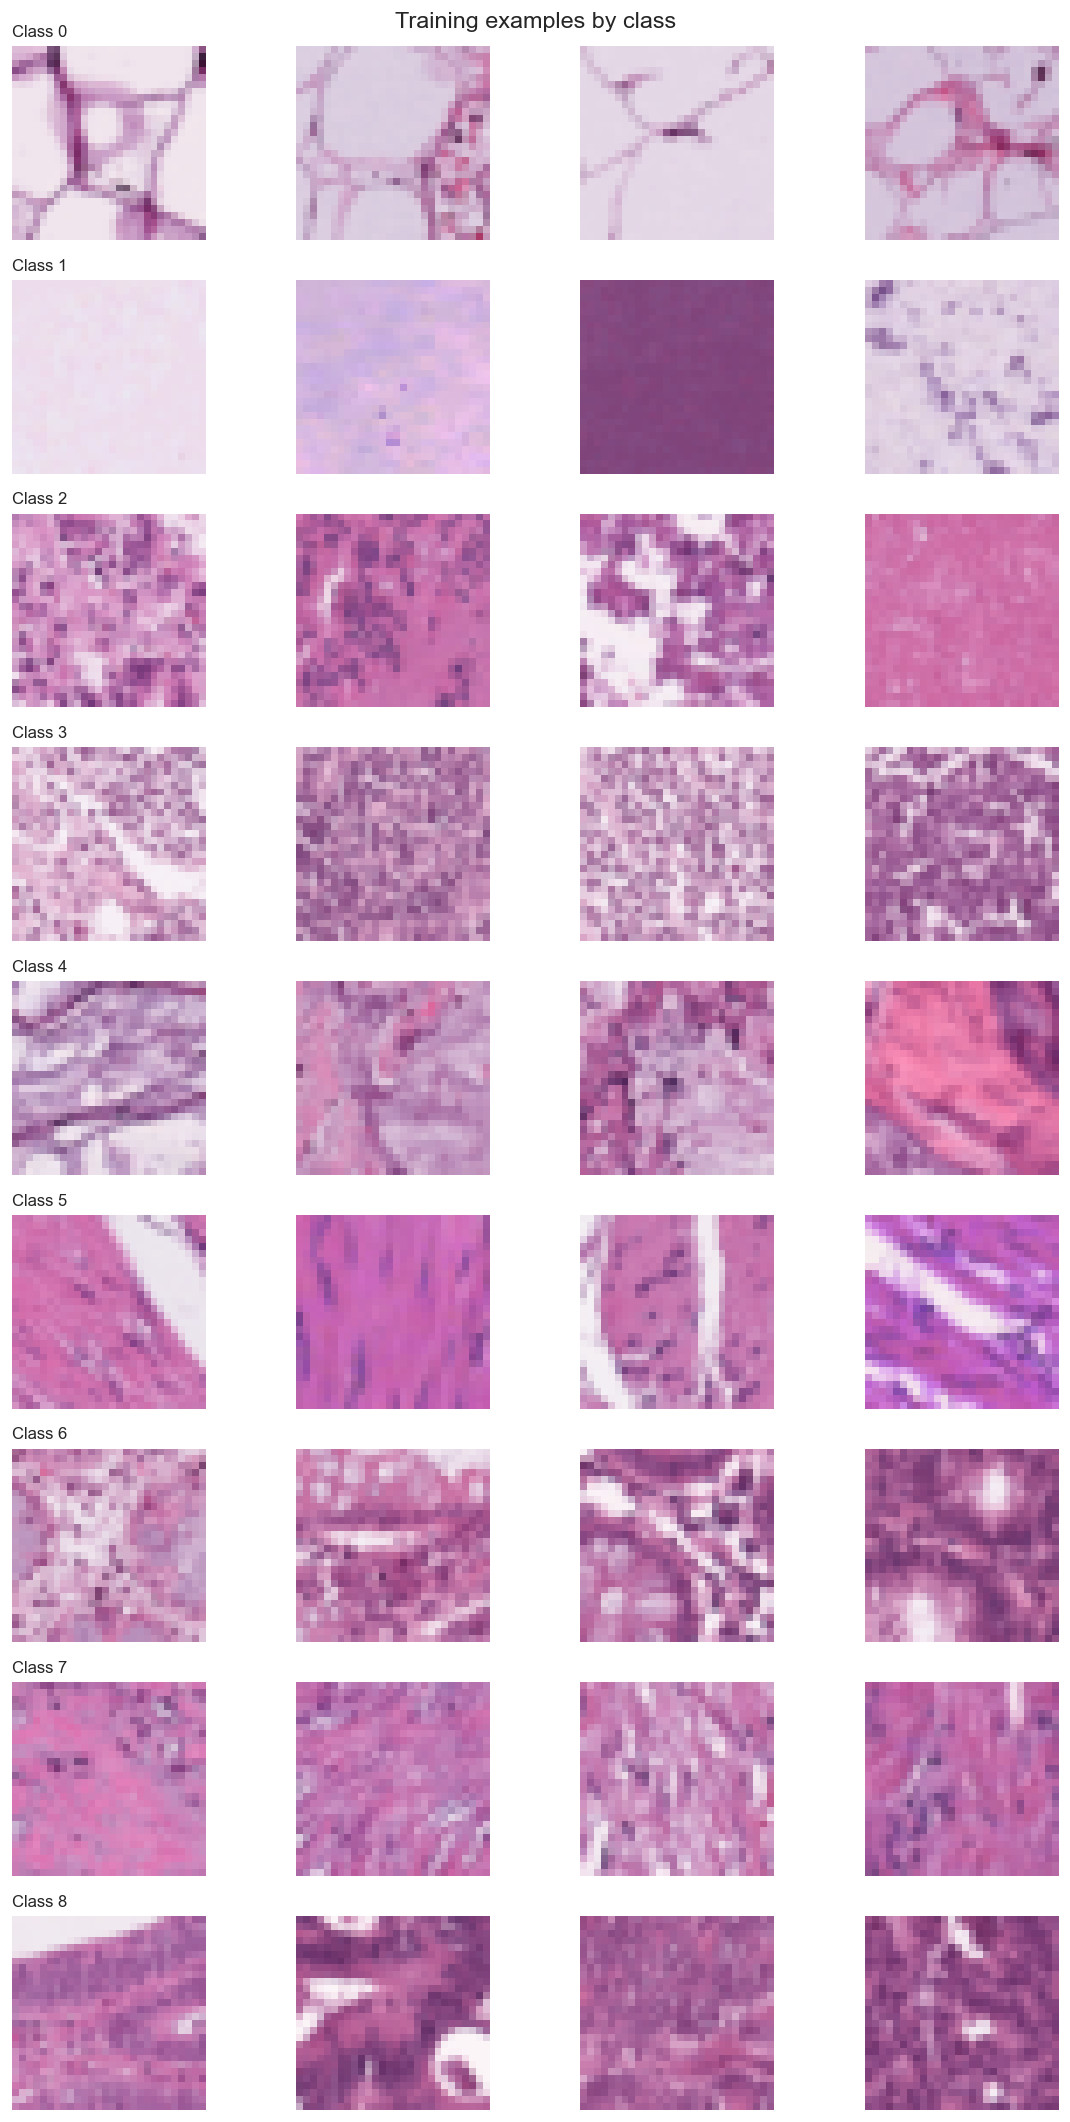

In [6]:
samples_per_class = 4
fig, axes = plt.subplots(len(class_ids), samples_per_class, figsize=(10, 18))

for row, class_id in enumerate(class_ids):
    sample_indices = np.where(y_train == class_id)[0][:samples_per_class]
    for col, sample_idx in enumerate(sample_indices):
        axes[row, col].imshow(X_train[sample_idx])
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(f'Class {class_id}', loc='left', fontsize=10)

fig.suptitle('Training examples by class', fontsize=14)
fig.tight_layout()
fig.savefig(output_dir / 'sample_images_by_class.png', bbox_inches='tight')
plt.show()

### Pixel intensity distribution
Plotting the raw pixel values helps justify scaling images to the [0, 1] range.

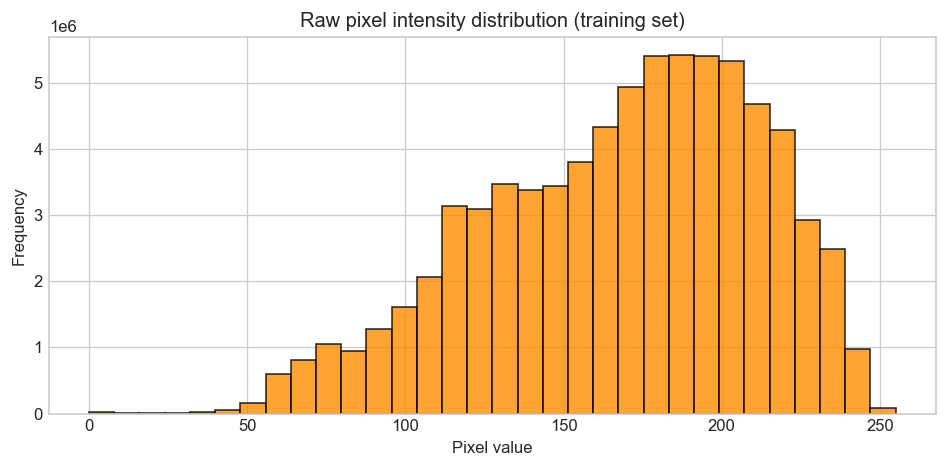

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(X_train.reshape(-1), bins=32, color='darkorange', edgecolor='black', alpha=0.8)
ax.set_title('Raw pixel intensity distribution (training set)')
ax.set_xlabel('Pixel value')
ax.set_ylabel('Frequency')
fig.tight_layout()
fig.savefig(output_dir / 'pixel_distribution.png', bbox_inches='tight')
plt.show()

### Preprocessing
The minimal preprocessing used here is image normalisation to float32 values in [0, 1], followed by a stratified train/validation split and a flattened copy for non-CNN models.

In [8]:
X_train_norm = X_train.astype(np.float32) / 255.0
X_test_norm = X_test.astype(np.float32) / 255.0

X_train_img, X_val_img, y_train_split, y_val = train_test_split(
    X_train_norm,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

X_train_flat = X_train_img.reshape(X_train_img.shape[0], -1)
X_val_flat = X_val_img.reshape(X_val_img.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

np.save(processed_dir / 'X_train_img.npy', X_train_img)
np.save(processed_dir / 'X_val_img.npy', X_val_img)
np.save(processed_dir / 'X_test_img.npy', X_test_norm)
np.save(processed_dir / 'X_train_flat.npy', X_train_flat)
np.save(processed_dir / 'X_val_flat.npy', X_val_flat)
np.save(processed_dir / 'X_test_flat.npy', X_test_flat)
np.save(processed_dir / 'y_train.npy', y_train_split)
np.save(processed_dir / 'y_val.npy', y_val)
np.save(processed_dir / 'y_test.npy', y_test)

print('Saved processed arrays to:', processed_dir.resolve())
print(f'X_train_img shape: {X_train_img.shape}')
print(f'X_val_img shape: {X_val_img.shape}')
print(f'X_test_img shape: {X_test_norm.shape}')
print(f'X_train_flat shape: {X_train_flat.shape}')

Saved processed arrays to: /Users/hao/code/Com5318/COMP5318-Assignment-2/processed
X_train_img shape: (25600, 28, 28, 3)
X_val_img shape: (6400, 28, 28, 3)
X_test_img shape: (8000, 28, 28, 3)
X_train_flat shape: (25600, 2352)


### Examples of preprocessed data
The figure below compares raw and normalised images. The normalised images look visually similar, but their datatype and numeric range are now more suitable for model training.

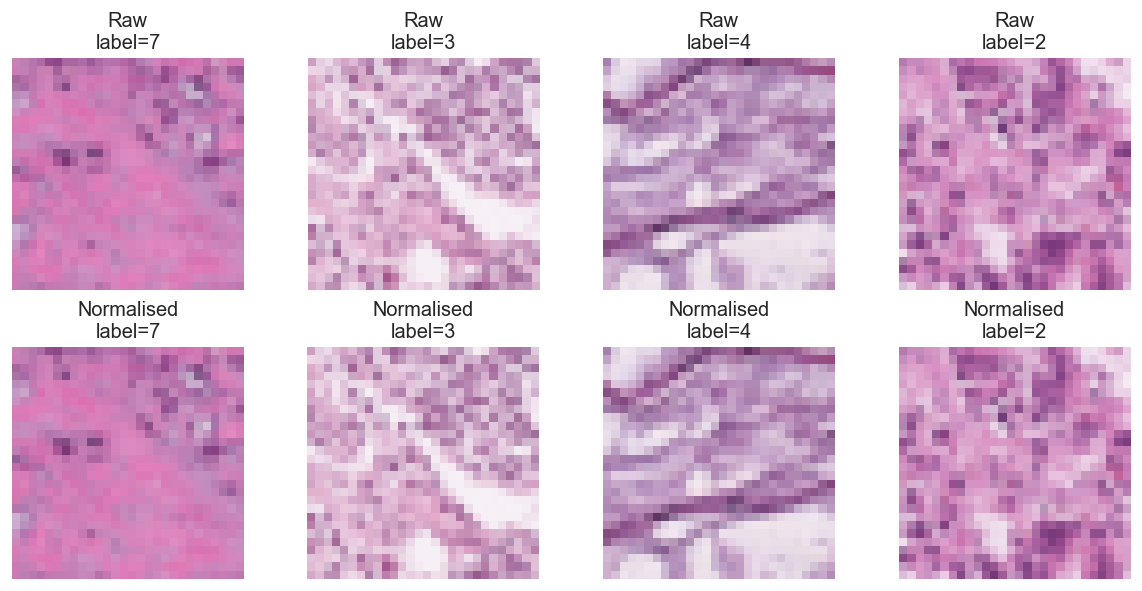

Normalised training range: [0.000, 1.000]
Flattened feature count per image: 2352


In [9]:
comparison_indices = [0, 1, 2, 3]
fig, axes = plt.subplots(2, len(comparison_indices), figsize=(10, 5))

for col, sample_idx in enumerate(comparison_indices):
    axes[0, col].imshow(X_train[sample_idx])
    axes[0, col].set_title(f'Raw\nlabel={y_train[sample_idx]}')
    axes[0, col].axis('off')

    axes[1, col].imshow(X_train_norm[sample_idx])
    axes[1, col].set_title(f'Normalised\nlabel={y_train[sample_idx]}')
    axes[1, col].axis('off')

fig.tight_layout()
fig.savefig(output_dir / 'preprocessing_comparison.png', bbox_inches='tight')
plt.show()

print(f'Normalised training range: [{X_train_norm.min():.3f}, {X_train_norm.max():.3f}]')
print(f'Flattened feature count per image: {X_train_flat.shape[1]}')

## 2. Algorithm design and setup

### Algorithm of choice from first six weeks of course

### Fully connected neural network
In this architecture, a series of hidden dense layers with ReLU activation are utilized to extract non-linear representations, followed by dropout regularization to improve generalization. Unlike CNNs, MLPs cannot directly process spatial dimensions; therefore, the 28×28×3 PathMNIST images are flattened into a 1D vector, resulting in an input shape of (2352,). The final output layer consists of 9 neurons, outputting the probability distribution for the 9 disease categories.

In [18]:
keras.backend.clear_session() 
tf.random.set_seed(RANDOM_STATE) 

num_classes = len(np.unique(y_train_split))

def build_mlp_model(
    n_hidden_layers=2, 
    n_hidden_neurons=256,
    activation_function="relu", 
    dropout_rate=0.3,
    input_shape=None
):
    model = keras.models.Sequential()
    # Automatically obtain feature dimensions
    model.add(keras.layers.Input(shape=input_shape)) 
    
    for layer in range(n_hidden_layers):
        model.add(keras.layers.Dense(n_hidden_neurons, activation=activation_function))
        model.add(keras.layers.Dropout(dropout_rate))
        
    model.add(keras.layers.Dense(num_classes, activation="softmax"))
    return model


mlp_classifier = KerasClassifier(
    model=build_mlp_model,
    n_hidden_layers=2,
    n_hidden_neurons=256,
    activation_function="relu",
    dropout_rate=0.3,
    input_shape=(X_train_flat.shape[1],),
    
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    optimizer__learning_rate=0.001,
    metrics=["accuracy"],
    
    epochs=20,
    batch_size=64,
    verbose=0
)

mlp_model_instance = build_mlp_model(input_shape=(X_train_flat.shape[1],))
mlp_model_instance.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       602,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 670,473 (2.56 MB)

 Trainable params: 670,473 (2.56 MB)

 Non-trainable params: 0 (0.00 B)

### Convolutional neural network
In this CNN, two convolutional layers are used to extract local image features, followed by max pooling to reduce the spatial dimensions, and finally a dense layer for classification. Since PathMNIST consists of 28×28 color images, the input shape is (28, 28, 3). The output layer has 9 neurons, corresponding to the 9 categories.

In [11]:
num_classes = len(np.unique(y_train_split))
input_shape = X_train_img.shape[1:]

def build_cnn_model(
    conv_filters=32,
    dense_units=128,
    dropout_rate=0.3,
    learning_rate=0.001
):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(conv_filters, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(conv_filters * 2, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


cnn_model = build_cnn_model()
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,089 (1.61 MB)

 Trainable params: 422,089 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Hyperparameter tuning

### Algorithm of choice from first six weeks of course

### Fully connected neural network
Multi-layer perceptron
In accordance with the assignment requirements, four key hyperparameters have been explicitly selected for exhaustive tuning to optimize the model's performance on the PathMNIST dataset.

Network Architecture: The capacity of the model is explored by varying the depth (n_hidden_layers: 1, 2, 3) and width (n_hidden_neurons: 128, 256, 512) of the network.

Regularization: To mitigate the high risk of overfitting inherent in fully connected networks processing flattened image data, different dropout_rate values ​​(0.2, 0.3, 0.4) are evaluated.

Optimization: The learning_rate (0.001, 0.0005) for the Adam optimizer is tuned to find the best balance between convergence speed and finding the global minimum.

This comprehensive grid search results in a total of 54 unique hyperparameter combinations.

In [21]:
mlp_param_grid = {
    'n_hidden_layers': [1, 2, 3],
    'n_hidden_neurons': [128, 256, 512],
    'dropout_rate': [0.2, 0.3, 0.4],
    'optimizer__learning_rate': [0.001, 0.0005] 
}

grid_search_cv = GridSearchCV(mlp_classifier, mlp_param_grid, cv=2, verbose=2, n_jobs=-1)

start_time = time.time()
grid_search_cv.fit(X_train_flat, y_train_split, epochs=10)
print(f"\nGrid search complete! Overall workflow: {(time.time() - start_time) / 60:.2f} mins")

Fitting 2 folds for each of 54 candidates, totalling 108 fits
[CV] END dropout_rate=0.2, n_hidden_layers=1, n_hidden_neurons=256, optimizer__learning_rate=0.0005; total time=  53.6s
[CV] END dropout_rate=0.2, n_hidden_layers=1, n_hidden_neurons=256, optimizer__learning_rate=0.001; total time=  53.9s
[CV] END dropout_rate=0.2, n_hidden_layers=1, n_hidden_neurons=256, optimizer__learning_rate=0.0005; total time=  54.0s
[CV] END dropout_rate=0.2, n_hidden_layers=1, n_hidden_neurons=512, optimizer__learning_rate=0.001; total time=  54.4s
[CV] END dropout_rate=0.2, n_hidden_layers=1, n_hidden_neurons=256, optimizer__learning_rate=0.001; total time=  54.5s
[CV] END dropout_rate=0.2, n_hidden_layers=1, n_hidden_neurons=128, optimizer__learning_rate=0.001; total time=  54.7s
[CV] END dropout_rate=0.2, n_hidden_layers=1, n_hidden_neurons=128, optimizer__learning_rate=0.001; total time=  54.7s
[CV] END dropout_rate=0.2, n_hidden_layers=1, n_hidden_neurons=128, optimizer__learning_rate=0.0005; to

2026-05-04 16:40:59.842853: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.



Grid search complete! Overall workflow: 12.49 mins


In [33]:
mlp_tuning_results_df = pd.DataFrame(grid_search_cv.cv_results_)

display_cols = ['param_n_hidden_layers', 'param_n_hidden_neurons', 
                'param_dropout_rate', 'param_optimizer__learning_rate', 
                'mean_test_score']

top_5_results = mlp_tuning_results_df[display_cols].sort_values(by='mean_test_score', ascending=False).head(10)
print("\n--- Top 5 combinations ---")
display(top_5_results)


--- Top 5 combinations ---


,param_n_hidden_layers,param_n_hidden_neurons,param_dropout_rate,param_optimizer__learning_rate,mean_test_score
5,1,512,0.2,0.0005,0.325039
3,1,256,0.2,0.0005,0.319141
40,1,512,0.4,0.0010,0.307305
19,1,128,0.3,0.0005,0.303203
41,1,512,0.4,0.0005,0.298438
4,1,512,0.2,0.0010,0.297148
7,2,128,0.2,0.0005,0.294805
37,1,128,0.4,0.0005,0.294219
27,2,256,0.3,0.0005,0.294102
39,1,256,0.4,0.0005,0.293125


In [31]:
print(f"Highest cross-validation accuracy on the validation set (CV Score): {grid_search_cv.best_score_:.4f}")
print("The optimal combination of hyperparameters found:")
for param, value in grid_search_cv.best_params_.items():
    print(f"  {param}: {value}")

Highest cross-validation accuracy on the validation set (CV Score): 0.3250
The optimal combination of hyperparameters found:
  dropout_rate: 0.2
  n_hidden_layers: 1
  n_hidden_neurons: 512
  optimizer__learning_rate: 0.0005


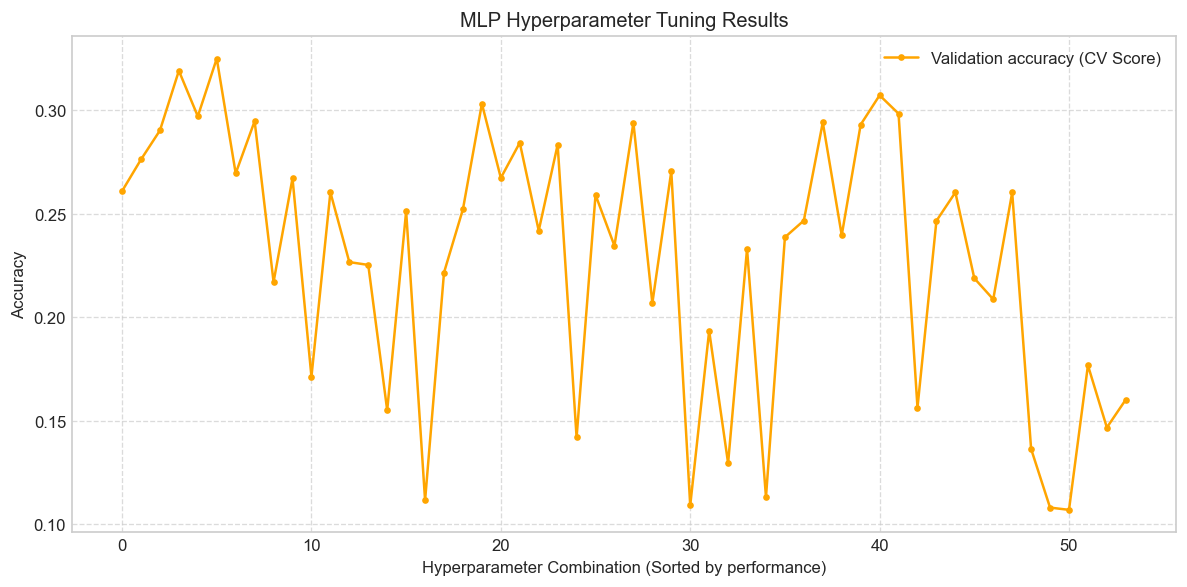

In [34]:
fig, ax = plt.subplots(figsize=(10, 5)) 

ax.plot(
    range(len(mlp_tuning_results_df)),
    mlp_tuning_results_df['mean_test_score'],
    marker='.', 
    linestyle='-',
    color='orange',
    label='Validation accuracy (CV Score)'
)

ax.set_title('MLP Hyperparameter Tuning Results')
ax.set_xlabel('Hyperparameter Combination (Sorted by performance)')
ax.set_ylabel('Accuracy')
ax.legend()

ax.grid(True, linestyle='--', alpha=0.7)

fig.tight_layout()
fig.savefig(output_dir / 'mlp_hyperparameter_tuning.png', bbox_inches='tight', dpi=300)
plt.show()

### Convolutional neural network
In accordance with the assignment requirements, 4 hyperparameters have been selected for tuning.

In [ ]:
cnn_param_grid = [
    {'conv_filters': 16, 'dense_units': 64,  'dropout_rate': 0.2, 'learning_rate': 0.001},
    {'conv_filters': 16, 'dense_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001},
    {'conv_filters': 32, 'dense_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001},
    {'conv_filters': 32, 'dense_units': 128, 'dropout_rate': 0.5, 'learning_rate': 0.001},
    {'conv_filters': 32, 'dense_units': 256, 'dropout_rate': 0.3, 'learning_rate': 0.0005},
]

cnn_tuning_results = []

for params in cnn_param_grid:
    print('Training CNN with:', params)

    keras.backend.clear_session()
    cnn_model = build_cnn_model(**params)

    start_time = time.time()

    cnn_history = cnn_model.fit(
        X_train_img,
        y_train_split,
        validation_data=(X_val_img, y_val),
        epochs=10,
        batch_size=128,
        verbose=0
    )

    runtime = time.time() - start_time

    train_accuracy = cnn_history.history['accuracy'][-1]
    val_accuracy = cnn_history.history['val_accuracy'][-1]
    train_loss = cnn_history.history['loss'][-1]
    val_loss = cnn_history.history['val_loss'][-1]

    cnn_tuning_results.append({
        'conv_filters': params['conv_filters'],
        'dense_units': params['dense_units'],
        'dropout_rate': params['dropout_rate'],
        'learning_rate': params['learning_rate'],
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'runtime_seconds': runtime
    })

cnn_tuning_results_df = pd.DataFrame(cnn_tuning_results)
cnn_tuning_results_df

Training CNN with: {'conv_filters': 16, 'dense_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.001}


Then select the optimal parameters and save the results.

In [ ]:
best_cnn_row = cnn_tuning_results_df.loc[cnn_tuning_results_df['val_accuracy'].idxmax()]
best_cnn_params = {
    'conv_filters': int(best_cnn_row['conv_filters']),
    'dense_units': int(best_cnn_row['dense_units']),
    'dropout_rate': float(best_cnn_row['dropout_rate']),
    'learning_rate': float(best_cnn_row['learning_rate'])
}

best_cnn_params

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    range(len(cnn_tuning_results_df)),
    cnn_tuning_results_df['train_accuracy'],
    marker='o',
    label='Training accuracy'
)

ax.plot(
    range(len(cnn_tuning_results_df)),
    cnn_tuning_results_df['val_accuracy'],
    marker='o',
    label='Validation accuracy'
)

ax.set_title('CNN hyperparameter tuning results')
ax.set_xlabel('Hyperparameter combination')
ax.set_ylabel('Accuracy')
ax.legend()

fig.tight_layout()
fig.savefig(output_dir / 'cnn_hyperparameter_tuning.png', bbox_inches='tight')
plt.show()

## 4. Final models
In this section, please ensure to include cells to train each model with its best hyperparmater combination independently of the hyperparameter tuning cells, i.e. don't rely on the hyperparameter tuning cells having been run.

### Algorithm of choice from first six weeks of course

### Fully connected neural network

In [36]:
best_mlp_model = grid_search_cv.best_estimator_

# Test Set Evaluation
y_pred_mlp = best_mlp_model.predict(X_test_flat)

test_accuracy = accuracy_score(y_test, y_pred_mlp)
print(f"\n Accuracy of MLP model on test set: {test_accuracy:.4f}")


# Print Categorized Report
print("\n--- (Classification Report) ---")
print(classification_report(y_test, y_pred_mlp, digits=4, zero_division=0))


 Accuracy of MLP model on test set: 0.2919

--- (Classification Report) ---
              precision    recall  f1-score   support

           0     0.7115    0.9576    0.8164       873
           1     0.3811    0.5734    0.4579       858
           2     0.0249    0.0068    0.0107       877
           3     0.3091    0.0372    0.0664       914
           4     0.3880    0.1669    0.2334       737
           5     0.1734    0.7836    0.2839      1072
           6     0.1905    0.0059    0.0114       682
           7     0.0000    0.0000    0.0000       813
           8     0.0000    0.0000    0.0000      1174

    accuracy                         0.2919      8000
   macro avg     0.2420    0.2813    0.2089      8000
weighted avg     0.2318    0.2919    0.2075      8000



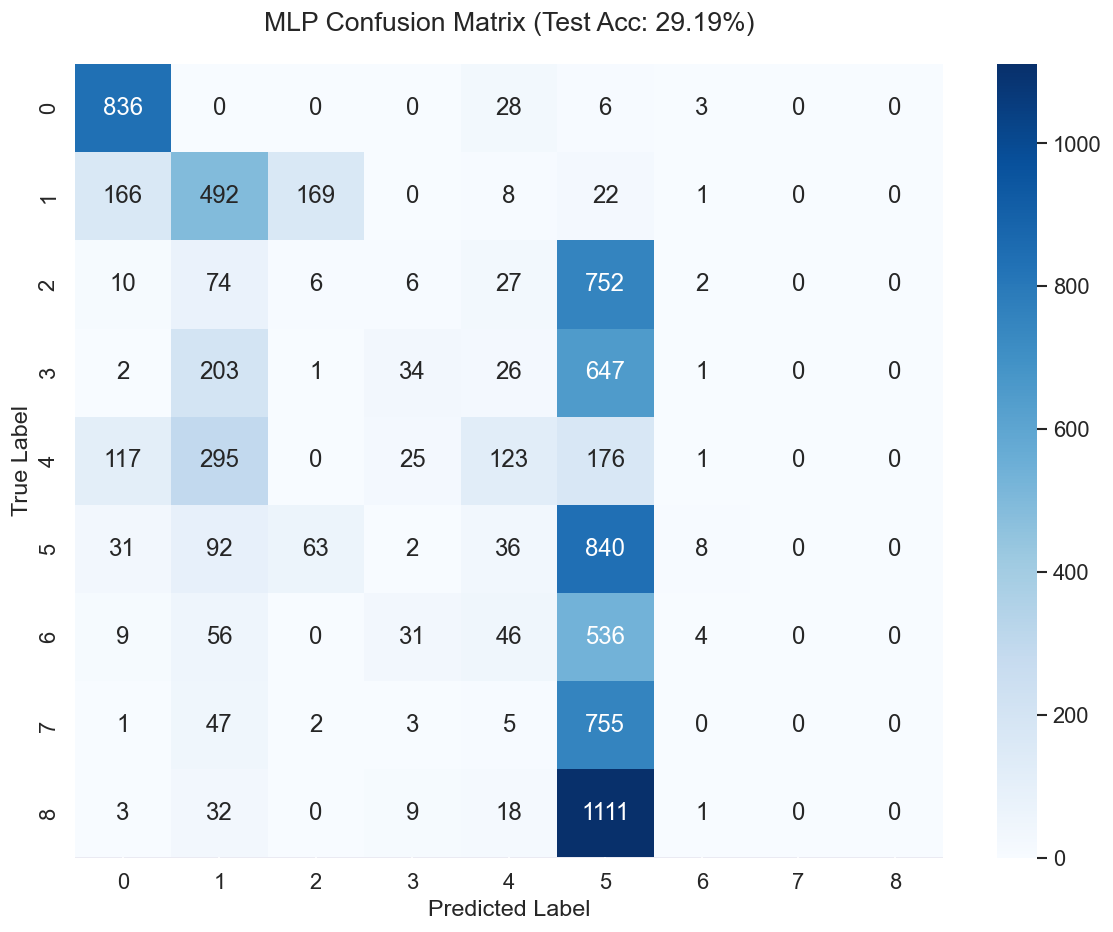

In [40]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_mlp)


plt.figure(figsize=(10, 8))
sns.set_theme(font_scale=1.2)

# Drawing a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))

plt.title(f'MLP Confusion Matrix (Test Acc: {test_accuracy:.2%})', pad=20, fontsize=16)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.tight_layout()

# 
plt.savefig(output_dir / 'mlp_confusion_matrix.png', dpi=300)
plt.show()

### Convolutional neural network

In [ ]:
keras.backend.clear_session()

final_cnn_model = build_cnn_model(**best_cnn_params)

start_time = time.time()

final_cnn_history = final_cnn_model.fit(
    X_train_img,
    y_train_split,
    validation_data=(X_val_img, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

final_cnn_runtime = time.time() - start_time

In [ ]:
# Test Set Evaluation
cnn_test_loss, cnn_test_accuracy = final_cnn_model.evaluate(
    X_test_img,
    y_test,
    verbose=0
)

cnn_test_probabilities = final_cnn_model.predict(X_test_img)
cnn_test_predictions = np.argmax(cnn_test_probabilities, axis=1)

print(f'CNN test accuracy: {cnn_test_accuracy:.4f}')
print(f'CNN test loss: {cnn_test_loss:.4f}')
print(f'CNN final training runtime: {final_cnn_runtime:.2f} seconds')

In [ ]:
# Print Categorized Report
print(classification_report(y_test, cnn_test_predictions, zero_division=0))

In [ ]:
# Confusion matrix
cnn_confusion_matrix = confusion_matrix(y_test, cnn_test_predictions)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cnn_confusion_matrix)

ax.set_title('CNN confusion matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))

fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(output_dir / 'cnn_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 5. AI Acknowledgement
Include acknowledgement of AI usage here. 
